# Bitcoin Price Forecasting: Building Predictive Models
## 1. Introduction
Welcome to the third phase of our Bitcoin analysis project: Time Series Forecasting. In this notebook, we will leverage the enriched historical Bitcoin data and the insights gained from our Exploratory Data Analysis (EDA) to build models that predict future price movements.

Forecasting cryptocurrency prices is inherently challenging due to their high volatility, sensitivity to external events, and speculative nature. However, by employing robust time series and machine learning techniques, we aim to gain an edge and understand potential future trends.

### Objectives of this Notebook:

- Load our pre-processed and feature-engineered Bitcoin historical data.

- Handle any remaining missing values in a data-driven way.

- Define our target variable for prediction (what we want to forecast).

- Strategically split our data into training, validation, and test sets to simulate real-world conditions.

- Implement and train two distinct types of forecasting models:

- ARIMA (AutoRegressive Integrated Moving Average): A classic statistical model for time series.

- XGBoost: A powerful gradient boosting machine learning model capable of leveraging our rich set of features.

- Evaluate the performance of our models using appropriate metrics.

- Generate and visualize future price forecasts.

- Discuss the implications for Bitcoin investment.

## 2. Setup and Data Loading
### 2.2 Import all necessary libraries

In [36]:
# --- Import Libraries --- #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Suppress warning for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Libraries for Forecasting Models
# ARIMA Library
import pmdarima as pm
from statsmodels.tsa.seasonal import seasonal_decompose # Already used in EDA, but good to have it if needed here.
from sklearn.metrics import mean_absolute_error, mean_squared_error

# For Machine Learning Models
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.model_selection import train_test_split # We'll use a custom time series split, but is good to have

# For model evaluation
from sklearn.preprocessing import StandardScaler

##### 2.2.1 Configure System Path to Load from src/ models


In [2]:
# This block ensures that the notebook can import modules from the 'src' directory.
current_notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_notebook_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"\nThis notebook directory path is: {current_notebook_dir}")
print(f"\nThe project directory path is: {project_root}")


This notebook directory path is: C:\Users\Leand\Desktop\2_Projects\1_BTCPriceAnalysis\notebooks

The project directory path is: C:\Users\Leand\Desktop\2_Projects\1_BTCPriceAnalysis


In [3]:
# -- Import functions from src/data_processing.py and scr/visualization_utils.py
from src.data_processing import (
    load_bitcoin_data,
    calculate_returns,
    calculate_moving_averages,
    calculate_volatility,
    calculate_rsi, 
    calculate_macd,
    calculate_bollinger_bands,
    create_lagged_features,
    create_event_features,
    run_adfuller_test
)
from src.visualization_utils import (
    plot_price_trend,
    plot_volume_trend,
    plot_correlation_heatmap,
    plot_returns_histogram,
    plot_distribution
)

## 3. Load and Re-engineer Data (to ensure consistency)

In [4]:
# --- Load the base data and reapply all feature engineering steps here --- #
# --- This will ensure this notebook is self-contained if you run it independently --- #
print("Loading base Bitcoin data and re-applying feature engineering...")
df = load_bitcoin_data()

df = create_event_features(df)
df = calculate_returns(df)
df = calculate_moving_averages(df, windows=[20, 50, 200])
df = calculate_volatility(df)
df = calculate_rsi(df)
df = calculate_macd(df)
df = calculate_bollinger_bands(df)
df = create_lagged_features(df, columns_to_lag=['Close', 'Volume', 'High', 'Low'], lags=[1, 7, 30])
# df = create_event_features(df)
# df = run_adfuller_test(df)

print("Data Loaded and features re-engineered successfully. DataFrame info:")
df.info()
print("\nFirst few rows of the enriched DataFame:")
print(df.head())

Loading base Bitcoin data and re-applying feature engineering...
Data Loaded and features re-engineered successfully. DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3948 entries, 2014-09-17 to 2025-07-08
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Open                       3948 non-null   float64
 1   High                       3948 non-null   float64
 2   Low                        3948 non-null   float64
 3   Close                      3948 non-null   float64
 4   Volume                     3948 non-null   int64  
 5   Halving_Event              3948 non-null   int64  
 6   Simple_Returns             3947 non-null   float64
 7   Log_Returns                3947 non-null   float64
 8   SMA_20                     3929 non-null   float64
 9   EMA_20                     3948 non-null   float64
 10  SMA_50                     3899 non-null   float64
 11  EMA_50  

### 3.1 Handling missing values (NaN)
###### Strategy: For simplicity and to retain the maximum amount of complete data, we will drop all rows containing any NaN values. This will effectively start our analysis from the first date when all features are available.

In [5]:
# --- Drop rows with NaN values --- #
print("\nHandling missing values by dropping rows with NaN...")
initial_rows = df.shape[0]
df_cleaned = df.dropna().copy()
final_rows = df_cleaned.shape[0]

print(f"\nOriginal rows: {initial_rows}")
print(f"Rows after dropping NaNs: {final_rows}")
print(f"Numbers of rows dropped: {initial_rows - final_rows}")

print("\nDataFrame info after dropping NaNs:")
df_cleaned.info()
print("\First few rows of the cleaned DataFrame:")
print(df_cleaned.head())


Handling missing values by dropping rows with NaN...

Original rows: 3948
Rows after dropping NaNs: 3749
Numbers of rows dropped: 199

DataFrame info after dropping NaNs:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3749 entries, 2015-04-04 to 2025-07-08
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Open                       3749 non-null   float64
 1   High                       3749 non-null   float64
 2   Low                        3749 non-null   float64
 3   Close                      3749 non-null   float64
 4   Volume                     3749 non-null   int64  
 5   Halving_Event              3749 non-null   int64  
 6   Simple_Returns             3749 non-null   float64
 7   Log_Returns                3749 non-null   float64
 8   SMA_20                     3749 non-null   float64
 9   EMA_20                     3749 non-null   float64
 10  SMA_50                    

## 4. Defining the Target Variable

What do we want to predict? Common choices in financial time series are:

- Next Day's Close Price: Directly forecasting the price. This is intuitive for investors, but can be harder for models due to non-stationarity.

- Next Day's Log Returns: Forecasting the percentage change. As our ADF test confirmed, log returns are stationary, which is beneficial for many models. We can then convert the predicted log return back to a price.

###### Recommendation: We will focus on predicting the Next Day's Log Returns. This approach is generally more robust for modeling due to the stationarity of returns, and it helps the model focus on predicting changes rather than absolute levels, which can be prone to drift. We can easily convert predicted returns back to predicted prices.

In [6]:
# --- Create Target Variable (Shifted Log Returns) --- # 
# We want to predict tomorrow's log return based on today's features.
# So our target 'y' will be the 'Log_Returns' column shifted *up* by 1.
df_cleaned['Target_Log_Returns'] = df_cleaned['Log_Returns'].shift(-1)

# Drop the last row where the target is NaN (because there's no next day's return)
df_model = df_cleaned.dropna(subset=['Target_Log_Returns']).copy()

print("\nDataFrame with 'Target_Log_Returns' Column:")
print(df_model.tail())
print(f"\nFinal number of rows for modeling: {df_model.shape[0]}")


DataFrame with 'Target_Log_Returns' Column:
                     Open           High            Low          Close  \
Date                                                                     
2025-07-03  108845.015625  110541.460938  108605.796875  109647.976562   
2025-07-04  109635.656250  109751.984375  107296.382812  108034.335938   
2025-07-05  108015.835938  108381.343750  107842.273438  108231.179688   
2025-07-06  108231.187500  109731.625000  107847.015625  109232.070312   
2025-07-07  109235.328125  109710.250000  107527.054688  108299.851562   

                 Volume  Halving_Event  Simple_Returns  Log_Returns  \
Date                                                                  
2025-07-03  50494742270              0        0.007245     0.007219   
2025-07-04  42616442656              0       -0.014717    -0.014826   
2025-07-05  30615537520              0        0.001822     0.001820   
2025-07-06  36746020463              0        0.009248     0.009205   
2025-07-07

## 5. Data Splitting: Training, Validation, and Test Sets

For time series data, a strict chronological split is essential to prevent data leakage. We cannot use future data to predict the past.

- Training Set: Earliest data, used to train the model.

- Validation Set: Intermediate data, used for hyperparameter tuning and model selection.

- Test Set: Latest data, unseen by the model during training/validation, used for final, unbiased evaluation of performance.

##### Splitting Strategy:

- Training: 80% of data

- Validation: 10% of data

- Test: 10% of data

### 5.1 Define Features (x) and Target (y)

In [7]:
# X will be all columns except the original Log_Returns and the new Target_Log_Returns,
# and also 'Open', 'High', 'Low' as they are highly correlated with 'Close'.
# We also include 'Close itself if we are predicting returns, as 'Close_Lag_1' already serves as a strong feature for this

# Let's define the features we want to use for our models
features = ['Close', 'Volume', 
            'SMA_20', 'SMA_50', 'SMA', 
            'Daily_Volatility', 'Annualized_Volatility_20D', 
            'High_Low_Range', 'High_Low_Percentage_Range', 'RSI', 
            'NACD_Line', 'MACD_Signal_Line', 'MACD_Histogram', 
            'Bollinger_Bands_Middle', 'Bollinger_Bands_Upper', 'Bollinger_Bands_Lower', 'Bollinger_Bands_Width', 
            'Close_Lag_1', 'Close_Lag_7', 'Close_Lag_30', 
            'Volume_Lag_1', 'Volume_Lag_7', 'Volume_Lag_30', 
            'High_Lag_1', 'High_Lag_7', 'High_Lag_30', 
            'Low_Lag_1', 'Low_Lag_7', 'Low_Lag_30', 
            'Halving_Event']

# Drop any feature that might have been dropped during NaN handling or are not present
features = [f for f in features if f in df_model.columns and f != 'Log_Returns'] # Exclude 'Log_Returns' itself

X = df_model[features]
y = df_model['Target_Log_Returns']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("\nSelected features for X:", features)


Features (X) shape: (3748, 27)
Target (y) shape: (3748,)

Selected features for X: ['Close', 'Volume', 'SMA_20', 'SMA_50', 'Annualized_Volatility_20D', 'High_Low_Range', 'High_Low_Percentage_Range', 'RSI', 'MACD_Signal_Line', 'MACD_Histogram', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Upper', 'Bollinger_Bands_Lower', 'Bollinger_Bands_Width', 'Close_Lag_1', 'Close_Lag_7', 'Close_Lag_30', 'Volume_Lag_1', 'Volume_Lag_7', 'Volume_Lag_30', 'High_Lag_1', 'High_Lag_7', 'High_Lag_30', 'Low_Lag_1', 'Low_Lag_7', 'Low_Lag_30', 'Halving_Event']


### 5.2 Chronological Split 

In [8]:
train_size = int(len(df_model) * 0.8)
val_size = int(len(df_model) * 0.1)
test_size = len(df_model) - train_size - val_size

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size + val_size], y.iloc[train_size:train_size + val_size]
X_test, y_test = X.iloc[train_size + val_size:], y.iloc[train_size + val_size:]

print(f"\nTraining set size: {len(X_train)} (from {X_train.index.min().strftime('%Y-%m-%d')} to {X_train.index.max().strftime('%Y-%m-%d')})")
print(f"Validation set size: {len(X_val)} (from {X_val.index.min().strftime('%Y-%m-%d')} to {X_val.index.max().strftime('%Y-%m-%d')})")
print(f"Training set size: {len(X_test)} (from {X_test.index.min().strftime('%Y-%m-%d')} to {X_test.index.max().strftime('%Y-%m-%d')})")



Training set size: 2998 (from 2015-04-04 to 2023-06-18)
Validation set size: 374 (from 2023-06-19 to 2024-06-26)
Training set size: 376 (from 2024-06-27 to 2025-07-07)


### 5.3 Feature Scaling (for ML models)

In [9]:
# Scale numerical features. Time series specific features like dates or events don't need scaling
# We'll fit scaler only on training data to prevent data leakage.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame with original index and columns for clarity if needed,
# but for most ML models, numpy arrays are fine.
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\nFeatures scaled sucessfully for ML models.")


Features scaled sucessfully for ML models.


## 6. Model Selection and Implementation
We will implement two distinct models to showcase different approaches: a statistical time series model (ARIMA) and a powerful machine learning model (XGBoost).

### 6.1. Model 1: ARIMA (AutoRegressive Integrated Moving Average)
ARIMA models are suitable for stationary time series. Since our Log_Returns are stationary, we can apply ARIMA directly to them. We'll use pmdarima's auto_arima to find the best ARIMA order automatically.


In [10]:
print("\n--- Training ARIMA Model ---")
# auto_arima automatically finds the best ARIMA (p,d,q) order.
# We'll use exogenous variables (X_train_scaled_df) to include our features.
# Since we are predicting Log_Returns, d=0 (Integrated component) is often suitable if the series is already stationary.
# However, auto_arima will determine the best 'd' itself

# fit auto_arima on the training data
arima_model = pm.auto_arima(y=y_train, 
                            exog=X_train_scaled_df,
                            start_p=1, start_q=1,
                            max_p=5, max_q=5, # Max order for p and q
                            d=None, Trace=True, # Let auto_arima find 'd'
                            error_action='ignore', # Don't want warning to stop search
                            supress_warning=True, # Suppress all warnings
                            stepwise=True, # Use stepwise algorithm for faster search
                            seasonal=False # Set to True if SARIMA is desired and period is known (e.g., weekly, monthly)
                           )
print("\nARIMA model Summary:")
print(arima_model.summary())


--- Training ARIMA Model ---

ARIMA model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2998
Model:                        SARIMAX   Log Likelihood                5574.534
Date:                Thu, 10 Jul 2025   AIC                         -11145.069
Time:                        20:24:03   BIC                         -11133.058
Sample:                    04-04-2015   HQIC                        -11140.748
                         - 06-18-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0016      0.001      2.212      0.027       0.000       0.003
sigma2         0.0014   1.44e-05     98.523      0.000       0.001       0.001


### 6.1.2 Make Predictions on Validation and Test Sets (Arima)

In [11]:
print("\nMaking ARIMA predictions on Validation and Test sets...")

# Predict on validation set
arima_val_pred = arima_model.predict(n_periods=len(X_val), exog=X_val_scaled_df)
arima_val_pred_series = pd.Series(arima_val_pred, index=y_val.index)

# Predict on test set
arima_test_pred = arima_model.predict(n_periods=len(X_test), exog=X_test_scaled_df)
arima_test_pred_series = pd.Series(arima_test_pred, index=y_test.index)


Making ARIMA predictions on Validation and Test sets...


### 6.1.3 Evaluate Model

In [19]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    # Drop NaNs and aligned indexes
    y_true, y_pred = y_true.align(y_pred, join='inner')
    mask = (~y_true.isna()) & (~y_pred.isna())
    
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    
    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    # MAPE is tricky with returns, as true returns can be zero or very close to zero.
    # We'll use a safer definition or stick to MAE/RMSE for returns.
    # If y_true contains 0, MAPE can be infinite.
    # mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100 # This can be problematic
    
    print(f"--- {model_name} Performance ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root mean Squared Error (RMSE): {rmse:.4f}")
    # print(f"Mean Absolute percentage Error (MAPE): {mape:.2f}%") # Use with caution for returns

evaluate_model(y_val, arima_val_pred_series, "ARIMA Validation")
evaluate_model(y_test, arima_test_pred_series, "ARIMA TEST")

--- ARIMA Validation Performance ---
Mean Absolute Error (MAE): 0.0168
Root mean Squared Error (RMSE): 0.0246
--- ARIMA TEST Performance ---
Mean Absolute Error (MAE): 0.0152
Root mean Squared Error (RMSE): 0.0169


## 6.2. Train the XGBoost Model

In [44]:
# print("\n--- Training XGBoost model ---")

# # Define XGBoost Regressor
# # We'll use some common hyperparameter, tuning can be done with X_val
# xgb_model = xgb.XGBRegressor(objective='reg:squarederror',
#                              n_estimators=1000, # Number of boosting rounds
#                              learning_rate=0.05, # Step size shrinkage
#                              max_depth=5, # Maximum depth of a tree
#                              subsample=0.8, # Subsample ratio of training instances
#                              colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree
#                              random_state=42,
#                              n_jobs=1 # Use all available cores
#                             )

# # Fit the model using scaled training data
# xgb_model.fit(X_train_scaled, y_train,
#               eval_set=[(X_val_scaled, y_val)], # Use validation set for early stopping
#               callbacks=[EarlyStopping(rounds=50, save_best=True)],
#               verbose=True # Set to True to see the training process
#              )

# print("XGBoost Model Trained.")

In [40]:
import xgboost as xgb
from xgboost.callback import EarlyStopping

In [41]:
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dval = xgb.DMatrix(X_val_scaled, label=y_val)

params = {
    'objective': 'reg:squarederror', 
    'learning_rate': '0.05', 
    'max_depth': '5', 
    'subsample': '0.8', 
    'colsample_bytree': '0.8', 
    'random_state': '42', 
    'eval_metric': 'rmse', 
}

evals = [(dtrain, 'train'), (dval, 'eval')]

booster = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=evals,
    callbacks=[EarlyStopping(rounds=50, save_best=True)],
    verbose_eval=True
)
print('XGBoost Model trained using xgb.train() with early stopping.')

[0]	train-rmse:0.03757	eval-rmse:0.02459
[1]	train-rmse:0.03742	eval-rmse:0.02461
[2]	train-rmse:0.03729	eval-rmse:0.02460
[3]	train-rmse:0.03711	eval-rmse:0.02458
[4]	train-rmse:0.03699	eval-rmse:0.02457
[5]	train-rmse:0.03683	eval-rmse:0.02458
[6]	train-rmse:0.03671	eval-rmse:0.02457
[7]	train-rmse:0.03654	eval-rmse:0.02456
[8]	train-rmse:0.03641	eval-rmse:0.02459
[9]	train-rmse:0.03630	eval-rmse:0.02460
[10]	train-rmse:0.03623	eval-rmse:0.02467
[11]	train-rmse:0.03617	eval-rmse:0.02468
[12]	train-rmse:0.03607	eval-rmse:0.02468
[13]	train-rmse:0.03599	eval-rmse:0.02470
[14]	train-rmse:0.03590	eval-rmse:0.02468
[15]	train-rmse:0.03582	eval-rmse:0.02470
[16]	train-rmse:0.03570	eval-rmse:0.02473
[17]	train-rmse:0.03560	eval-rmse:0.02475
[18]	train-rmse:0.03552	eval-rmse:0.02477
[19]	train-rmse:0.03537	eval-rmse:0.02480
[20]	train-rmse:0.03525	eval-rmse:0.02490
[21]	train-rmse:0.03521	eval-rmse:0.02497
[22]	train-rmse:0.03512	eval-rmse:0.02498
[23]	train-rmse:0.03505	eval-rmse:0.02506
[2

### 6.2.2 Make predictions on validation and test sets (XGBoost)

In [46]:
dval = xgb.DMatrix(X_val_scaled)
dtest = xgb.DMatrix(X_test_scaled)

# Make a prediction
xgb_val_pred = booster.predict(dval)
xgb_test_pred = booster.predict(dtest)

# Convert to Series to align them with the original indexes
xgb_val_pred_series = pd.Series(xgb_val_pred, index=y_val.index)
xgb_test_pred_series = pd.Series(xgb_test_pred, index=y_test.index)

In [47]:
# xgb_val_pred = xgb_model.predict(X_val_scaled)
# xgb_val_pred_seried = pd.Series(xgb_val_pred, index=y_val.index)

# xgb_test_pred = xgb_model.predict(X_test_scaled)
# xgb_test_pred_series = pd.Series(xgb_test_pred, index=y_test.index)
                                

In [48]:
def evaluate_model(y_true, y_pred, model_name='Mode'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {model_name} Performance Evaluation ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root mean Squared Error (RMSE): {rmse:.4f}")

evaluate_model(y_val, xgb_val_pred_series, "XGBoost Validation")
evaluate_model(y_test, xgb_test_pred_series, "XGBoost Test")

--- XGBoost Validation Performance Evaluation ---
Mean Absolute Error (MAE): 0.0168
Root mean Squared Error (RMSE): 0.0246
--- XGBoost Test Performance Evaluation ---
Mean Absolute Error (MAE): 0.0188
Root mean Squared Error (RMSE): 0.0260


## 7. Visualizing Forecasts
### 7.1 Compare Actual vs Predicted Returns

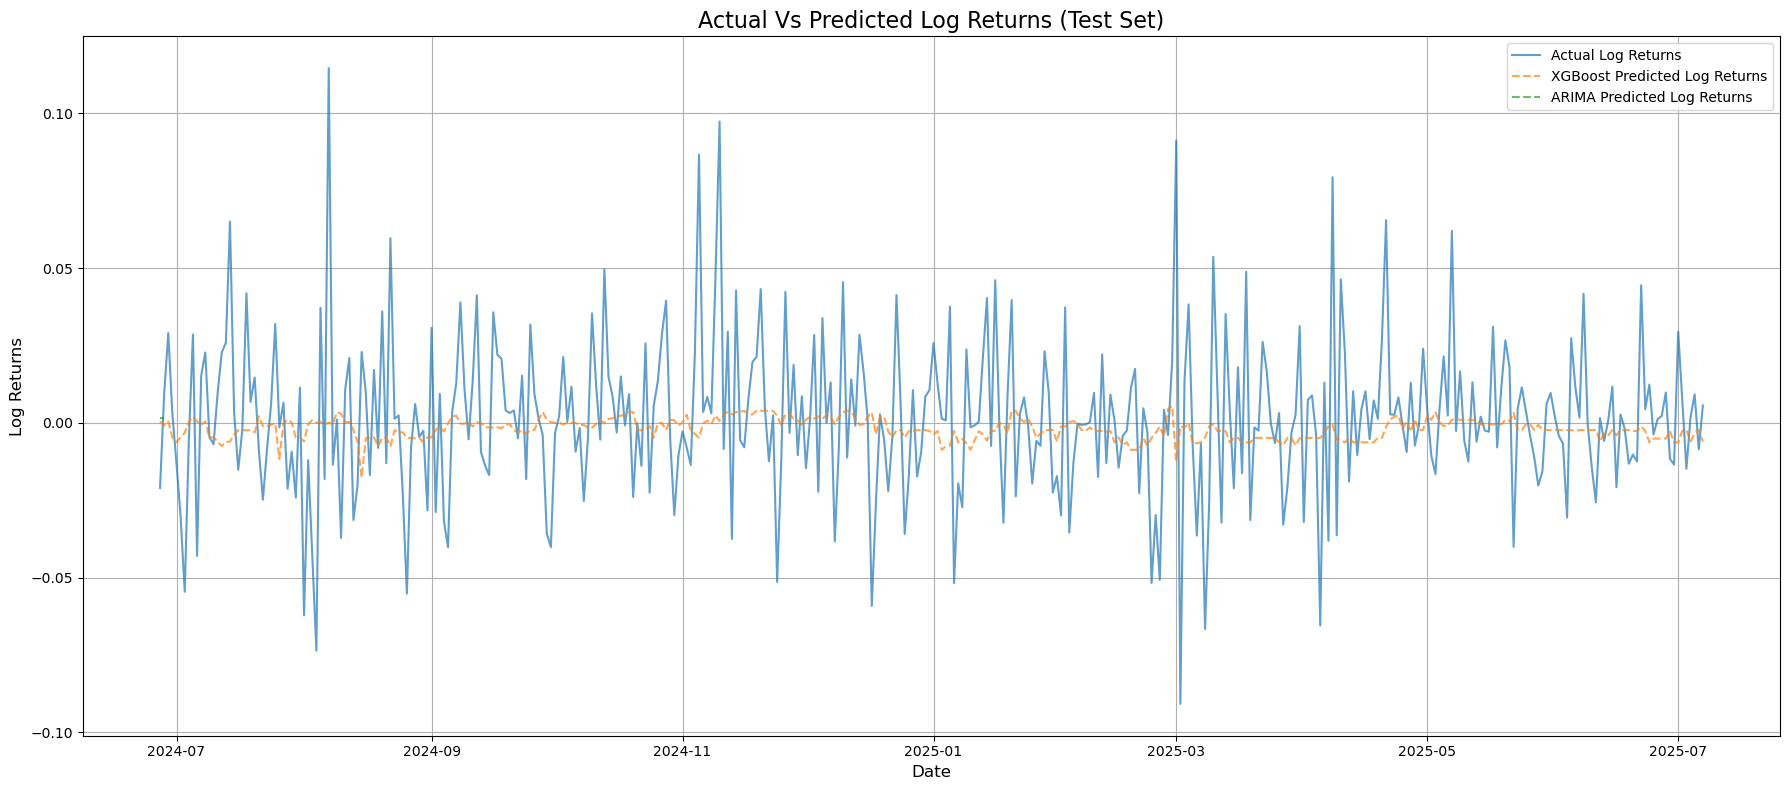

In [53]:
plt.figure(figsize=(18,8))
plt.plot(y_test.index, y_test, label='Actual Log Returns', alpha=0.7)
plt.plot(xgb_test_pred_series.index, xgb_test_pred_series, label='XGBoost Predicted Log Returns', linestyle='--', alpha=0.7)
plt.plot(arima_test_pred_series.index, arima_test_pred_series, label='ARIMA Predicted Log Returns', linestyle='--', alpha=0.7)
plt.title('Actual Vs Predicted Log Returns (Test Set)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Returns', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 7.2 Convert Predicted returns to predicted prices
Crucial step for the investor perspective. 
Predicted Price(t+1) = Current Price(t) * exp(Predicted Log Return(t+1))

In [55]:
#### 7.2.1 For XGBoost
actual_close_test = df_model.loc[y_test.index, 'Close'].shift(1).dropna() # Close price of dat rt, to predict day t+1
xgb_predicted_prices_test = actual_close_test * np.exp(xgb_test_pred_series.loc[actual_close_test.index])

In [56]:
#### 7.2.2 For ARIMA
arima_predicted_prices_test = actual_close_test * np.exp(arima_test_pred_series.loc[actual_close_test.index])

In [58]:
#### Actual prices for comparison
actual_prices_for_comparison = df_model.loc[y_test.index, 'Close']

In [59]:
#### 7.2.3 Align indices for plotting
xgb_predicted_prices_test = xgb_predicted_prices_test.reindex(actual_prices_for_comparison.index)
arima_predicted_prices_test = arima_predicted_prices_test.reindex(actual_prices_for_comparison.index)

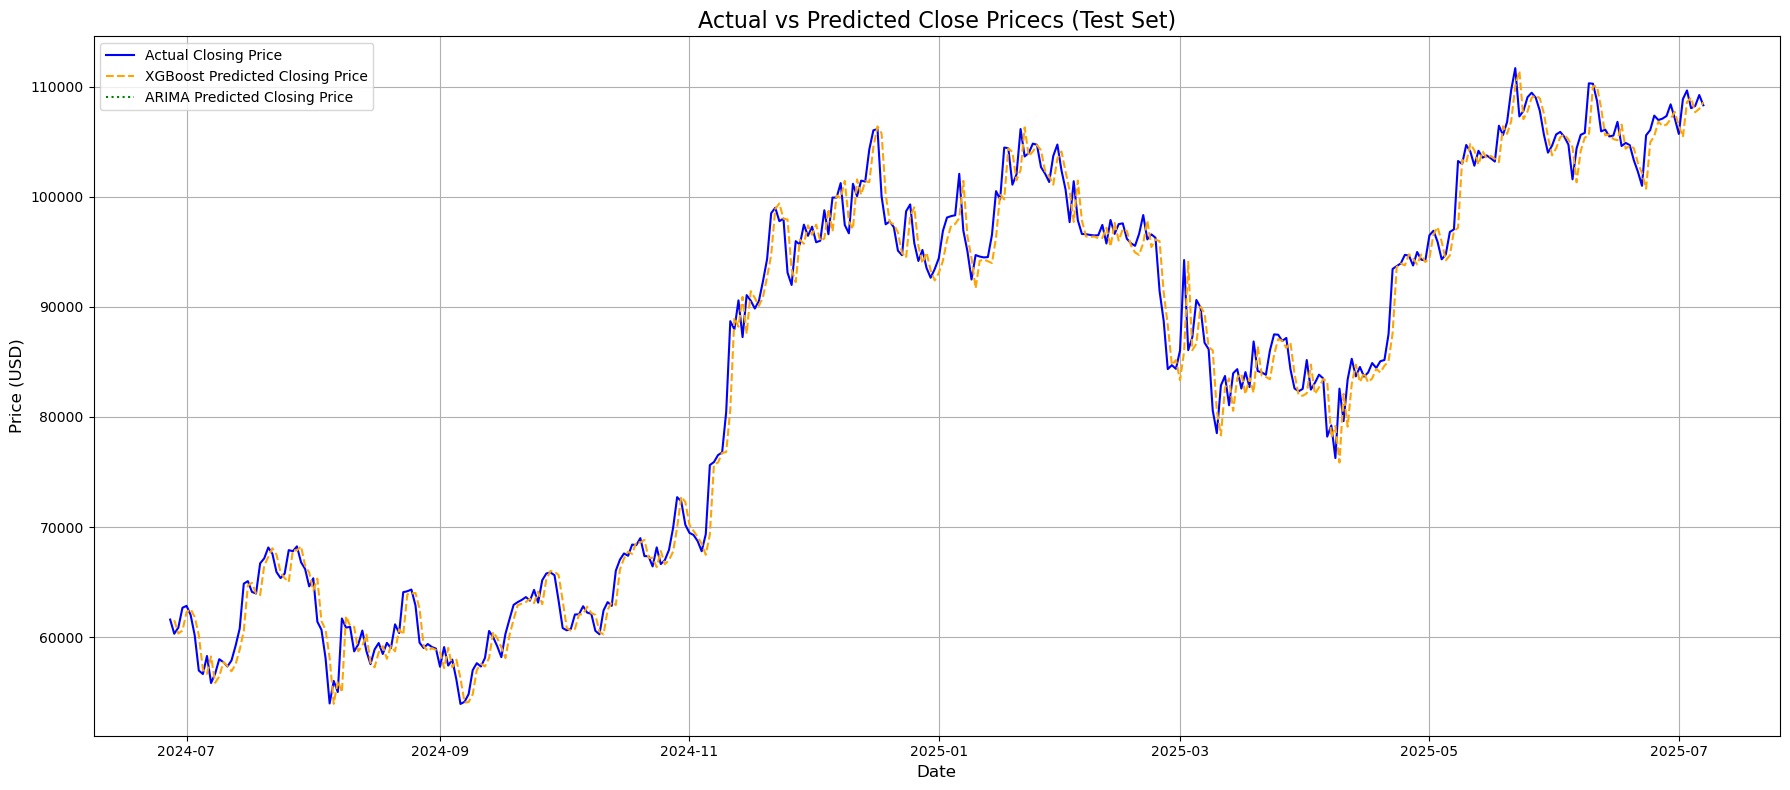

In [60]:
### 7.3 Compare Actual vs Predicted Prices
plt.figure(figsize=(18, 8))
plt.plot(actual_prices_for_comparison.index, actual_prices_for_comparison, label='Actual Closing Price', color='Blue')
plt.plot(xgb_predicted_prices_test.index, xgb_predicted_prices_test, label='XGBoost Predicted Closing Price', linestyle='--', color='orange')
plt.plot(arima_predicted_prices_test.index, arima_predicted_prices_test, label="ARIMA Predicted Closing Price", linestyle=':', color='green')

plt.title('Actual vs Predicted Close Pricecs (Test Set)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [65]:
### 7.4 Forecasting Future Days (Example for XGBoost)
print("\n--- Forecasting 7 future days using XGBoost ---")

# To forecast future days, you need the *latest* available features.
# Get the last row of  your full df_model (which represents the last known day)
last_known_data = df_model.tail(1)[features]

# You would need to simulate future feature values, which is the biggest challenge in real-world forecasting
# For demonstration, we'll use the last known values as a proxy for the next days' *features* (a simplification).
# In a real scenario, you'd need to separate the model or assumption for future feature values (e.g., using predicted MAs, etc.).

# Initialize an empty DataFrame for future predictions
future_forecast_df = pd.DataFrame(columns=['Predicted_Log_Returns', 'Predicted_Close_Price'])
last_close_price = df_model["Close"].iloc[-1]
last_index = df_model.index[-1]

# Number of future days to forecast
n_future_days = 7

# Loop to predict iteratively for future days
for i in range(1, n_future_days + 1):
    # Prepare features for prediction
    # This is a simplification: for real-world future prediction,
    # You'd need to forecast these features too (e.g., using predicted volume, next day's SMA based on predicted close, etc.).
    # For now, we'll use the last known features as input.
    current_features = last_known_data.copy()
    
    # Scale the current features using the *fitted* scaler
    current_features_scaled = scaler.transform(current_features)
    current_dmatrix = xgb.DMatrix(current_features_scaled)

    # Predict the log return for the next day
    next_log_return_pred = booster.predict(current_dmatrix)[0]
    # Calculate the predicted close price for the next day
    next_close_price_pred = last_close_price * np.exp(next_log_return_pred)

    # Store the prediction
    next_day_index = last_index + pd.Timedelta(days=i)
    future_forecast_df.loc[next_day_index] = [next_log_return_pred, next_close_price_pred]

    # Update last_close_price for the next iteration
    last_close_price = next_close_price_pred

    # In a more advanced setup, you would update 'last_know_data' with lagged features
    # based on the *newly predicted* close/volume etc.
    # For instance, current_features['Close_Lag_1'] would become the previous predicted closing price
    # This makes the loop more complex and requires careful management of feature updates

print("Future Forecasts:")
print(future_forecast_df)


--- Forecasting 7 future days using XGBoost ---
Future Forecasts:
            Predicted_Log_Returns  Predicted_Close_Price
2025-07-08              -0.006005          107651.474502
2025-07-09              -0.006005          107006.979191
2025-07-10              -0.006005          106366.342388
2025-07-11              -0.006005          105729.540995
2025-07-12              -0.006005          105096.552048
2025-07-13              -0.006005          104467.352723
2025-07-14              -0.006005          103841.920333


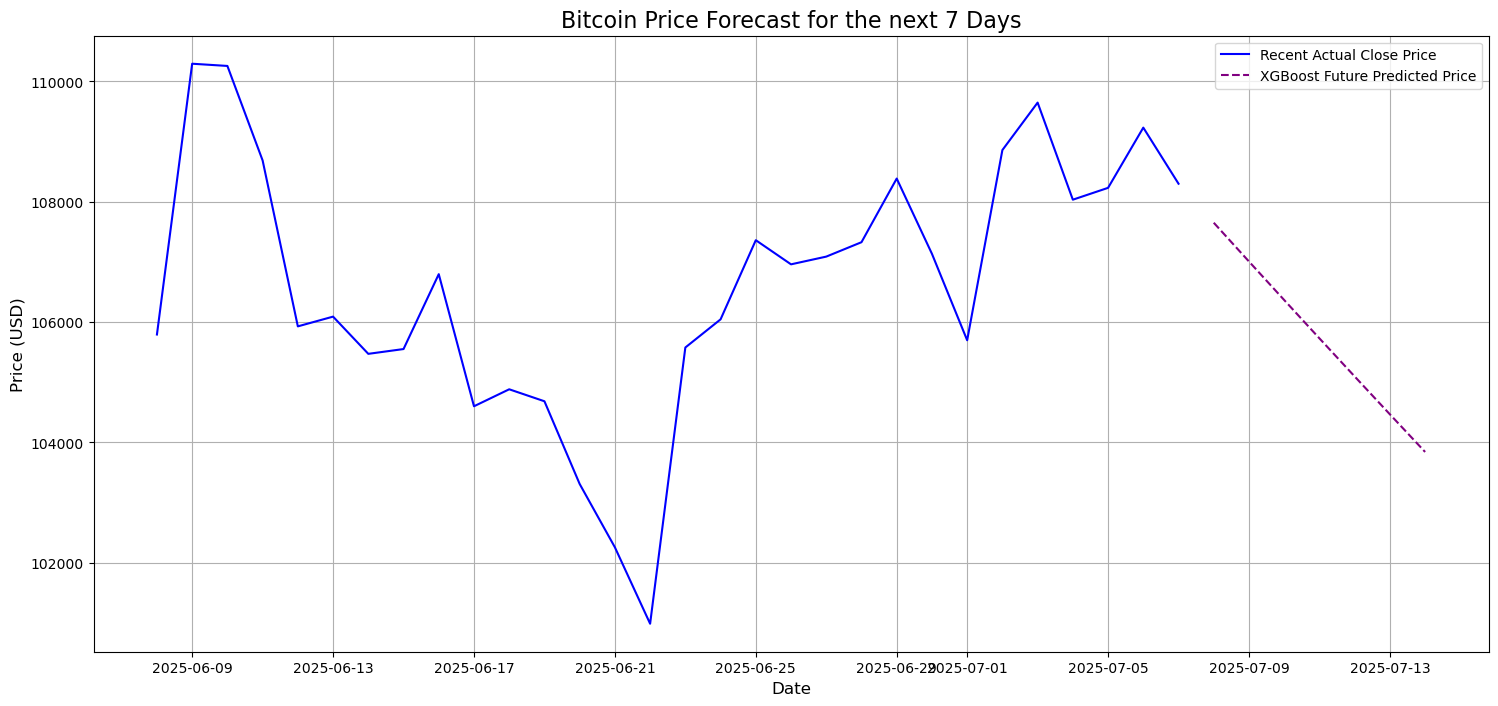

In [66]:
# plotting future forecast
plt.figure(figsize=(18, 8))
plt.plot(df_model['Close'].tail(30).index, df_model['Close'].tail(30), label='Recent Actual Close Price', color='blue') # plot recent actuals
plt.plot(future_forecast_df.index, future_forecast_df['Predicted_Close_Price'], label='XGBoost Future Predicted Price', linestyle='--', color='purple')
plt.title(f'Bitcoin Price Forecast for the next {n_future_days} Days', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout
plt.show()

## 8. Investment Implications and Model Limitations
For anyone considering using this model for investment, it's crucial to understand both its potential and its inherent limitations.

### How to Interpret the Predictions (for Investors):
- Predicted Log Returns: A positive predicted log return suggests an upward movement, while a negative one suggests a downward movement. The magnitude indicates the expected percentage change.

- Predicted Close Price: This is the most direct interpretation. It's the model's best estimate for the Bitcoin price on the forecast date.

- Trend vs. Exact Price: It's often more reliable to use these models to identify trends or directional movements (e.g., 'likely to go up', 'likely to go down') rather than relying on exact price points. Bitcoin's volatility makes precise point forecasts very challenging.

- Risk Management: Even if a model predicts an upward movement, always apply sound risk management principles. Never invest more than you can afford to lose.

### Model Limitations and Considerations:
Future Feature Uncertainty: Our future forecast example makes a strong simplification by using the last known features to predict future days. In a real-world scenario, you would need to forecast the future values of your features (like Volume, High/Low, and even the technical indicators like MAs, RSI, MACD, which depend on future prices). This is a complex problem often solved by:

- Using multi-variate time series models (e.g., VAR).

- Simulating future feature paths.

- Using simpler feature sets that don't rely on future data.

- Black Swan Events: Cryptocurrency markets are highly susceptible to sudden, unpredictable "black swan" events (e.g., major regulatory news, exchange hacks, global economic shocks). These models, based purely on historical data, cannot predict such unforeseen events. Our Halving_Event feature helps with known future events, but not truly unpredictable ones.

- Model Complexity vs. Interpretability: While XGBoost is powerful, understanding why it makes a specific prediction can be less straightforward than for simpler models.

- Data Quality and Lags: The quality of predictions heavily relies on the quality and relevance of your engineered features and the correctness of your lagged values.

- Overfitting: Always a risk in machine learning. Our train/val/test split helps mitigate this, but careful hyperparameter tuning is essential.

- Market Efficiency: The "Efficient Market Hypothesis" suggests that all available information is already priced in, making consistent outperformance through forecasting very difficult in liquid markets. Crypto markets are less efficient than traditional markets, but still challenging.

No Financial Advice: This model and its predictions are for educational and analytical purposes only. They do not constitute financial advice. Investment decisions should always be made after thorough personal research and consulting with a financial professional.

## 9. Refine and Stabilize Your Current Models

Before adding entirely new models or data, optimize what you have:

- Hyperparameter Tuning (XGBoost): Your XGBoost might be slightly overfitting. You can systematically tune its hyperparameters (e.g., n_estimators, learning_rate, max_depth, subsample, colsample_bytree, reg_alpha, reg_lambda) using techniques like GridSearchCV or RandomizedSearchCV to find a better balance between training and test performance.

- ARIMA Order Selection: Although pmdarima automates this, you can experiment with different p,d,q and P,D,Q,s orders for ARIMA manually or by reviewing the auto_arima summary to understand the chosen parameters better.

- Feature Importance Analysis (XGBoost): Use XGBoost's feature_importances_ attribute or SHAP values to understand which of your engineered features are most contributing to its predictions. This can guide future feature engineering.

- Residual Analysis (Both Models): Dive deeper into the residuals.

- Plot residuals over time to check for any remaining patterns or trends.

- Check for heteroskedasticity visually or with statistical tests (though your ARIMA summary already showed good results for Prob(H)).

- Analyze the distribution of residuals (beyond Jarque-Bera) to understand the nature of your errors.